# RaF X–A branching-ratio diagnostic

Question raised by inspection of the existing `BaF X-A.ipynb` table: the "Branching Ratio" column there was raw `|TDM|²` (no per-upper-state normalization), and the ground manifold was restricted to a single N. This notebook:

1. Builds X(N=0..5) and A(N=1..3) for RaF and diagonalizes at zero field.
2. Defines a **proper** branching-ratio routine: ν³-weighted, polarization-summed, normalized per upper state.
3. For each excited eigenstate of interest (A, J=1/2, ±), lists the **full** decay distribution across the whole X manifold and verifies sum = 1.
4. Compares against the "naïve" restriction to a single ground-N — quantifies what fraction was missed.

In [1]:
from config_path import add_to_sys_path
add_to_sys_path()

import numpy as np
import copy
from functools import partial
from tabulate import tabulate
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
sns.set_palette('bright')
np.set_printoptions(precision=5, suppress=True)

from Energy_Levels import MoleculeLevels, branching_ratios, Calculate_TDMs

c_cm = 29979.2458  # MHz / cm⁻¹

Added /Users/arianjadbabaie/Library/CloudStorage/GoogleDrive-arianjad@mit.edu/Shared drives/EMA-data-server/RaX/Personal/ArianJadbabaie/Code/Molecule-Structure/Source Code to sys.path


## States

X²Σ ground (RaF, $^{226}$Ra$^{19}$F) with N=0..5 — wide enough that any A-state decay (ΔJ≤1) is fully captured.

A²Π excited with N=1..3 — covers the J=1/2 and J=3/2 manifolds we excite for laser cooling.

In [2]:
X = MoleculeLevels.initialize_state(
    molecule_name='RaF', elec_state='X', vib_state=0,
    N_list=list(range(0, 6)),
    fermion_or_boson='boson',
    M_sublevels='all',
    I_nuclei=[0, 1/2],
    isotope=226,
    round=8,
    params=None,
    P_values=[1/2],
)

A = MoleculeLevels.initialize_state(
    molecule_name='RaF', elec_state='A', vib_state=0,
    N_list=[1, 2, 3],
    fermion_or_boson='boson',
    M_sublevels='all',
    I_nuclei=[0, 1/2],
    isotope=226,
    round=8,
    params=None,
    P_values=[1/2, 3/2],
)

E0_field, B0_field = 0.0, 1e-6
X.eigensystem(E0_field, B0_field)
A.eigensystem(E0_field, B0_field)

print(f"X size: {X.size}, A size: {A.size}")

X size: 144, A size: 152


## Proper branching ratio

`branching_ratios(G, E, Ez, Bz)` already returns `(G_evecs @ TDM @ E_evecs.T)**2` — i.e. $|\langle g | d | e \rangle|^2$ summed over polarization, in the eigenbasis. It does **not** normalize per upper state.

The Einstein-A branching ratio is

$$\mathrm{BR}_{e \to g} \;=\; \frac{\nu_{eg}^{3} \, |\langle g | d | e\rangle|^{2}}{\sum_{g'} \nu_{eg'}^{3} \, |\langle g' | d | e\rangle|^{2}}.$$

For X–A within v=0 the $\nu^3$ factor barely varies (electronic gap ≈ 1.4×10⁴ cm⁻¹ vs. rotational splittings ≤ 1 cm⁻¹), so the dominant correction relative to raw $|TDM|^2$ is the per-upper-state normalization.

In [3]:
def full_branching_ratios(X, A, Ez=0.0, Bz=1e-6, nu_weight=True):
    """Polarization-summed, ν³-weighted, per-upper-state-normalized BR.

    Returns
    -------
    BR : ndarray, shape (n_excited, n_ground)
        BR[j, i] = fraction of decays from excited eigenstate j that land on ground i.
        Each row sums to 1 (or 0 if no allowed decays).
    nu : ndarray, same shape, transition frequency (cm⁻¹), zero where unphysical.
    TDM2 : ndarray, same shape, polarization-summed |TDM|² in eigenbasis.
    """
    G_evals = X.eigensystem(Ez, Bz)[0] / c_cm
    E_evals = A.eigensystem(Ez, Bz)[0] / c_cm
    E_evals = E_evals + A.parameters['Origin']

    TDM2 = branching_ratios(X, A, Ez, Bz).T  # -> (n_excited, n_ground)

    nu = np.subtract.outer(E_evals, G_evals)
    nu = np.where(nu > 0, nu, 0.0)

    weight = nu**3 if nu_weight else np.ones_like(nu)
    raw = weight * TDM2
    row_sum = raw.sum(axis=1, keepdims=True)
    BR = np.divide(raw, row_sum, out=np.zeros_like(raw), where=row_sum > 0)
    return BR, nu, TDM2


def label_state(state, idx):
    """Compact quantum-number label for eigenstate idx of `state`."""
    qmax = np.argmax(state.evecs0[idx]**2)
    qn = state.q_numbers
    Ng = qn['N'][qmax] if 'N' in qn else None
    J = qn['J'][qmax]
    F = qn['F'][qmax]
    M = qn['M'][qmax]
    P = {1: '+', -1: '-'}[state.parities[idx]]
    if Ng is not None:
        return f"N={int(Ng)}{P}, J={J}, F={F}, M={M:+g}"
    return f"{P}, J={J}, F={F}, M={M:+g}"

## Compute BR for all excited eigenstates

In [4]:
BR, nu_cm, TDM2 = full_branching_ratios(X, A, Ez=E0_field, Bz=B0_field, nu_weight=True)
print("BR shape (n_excited, n_ground):", BR.shape)

row_sums = BR.sum(axis=1)
n_decaying = int((row_sums > 0.5).sum())
print(f"Excited states with row-sum ≈ 1: {n_decaying} / {BR.shape[0]}")
print(f"min row-sum (over decaying): {row_sums[row_sums > 0.5].min():.6f}")
print(f"max row-sum: {row_sums.max():.6f}")

Successfully converted eigenvectors from bBJ to aBJ


BR shape (n_excited, n_ground): (152, 144)
Excited states with row-sum ≈ 1: 152 / 152
min row-sum (over decaying): 1.000000
max row-sum: 1.000000


## Pick excited state(s) of interest

A J=1/2, both parities. This is the laser-cooling working manifold.

In [5]:
eidx_minus = A.select_q({'J': 0.5}, parity='-')
eidx_plus  = A.select_q({'J': 0.5}, parity='+')

print(f"A(J=1/2, −) eigenstates: {len(eidx_minus)}")
for j in eidx_minus:
    print(f"  [{j}]  {label_state(A, j)}   E = {A.evals0[j]/c_cm:.6f} cm⁻¹")
print()
print(f"A(J=1/2, +) eigenstates: {len(eidx_plus)}")
for j in eidx_plus:
    print(f"  [{j}]  {label_state(A, j)}   E = {A.evals0[j]/c_cm:.6f} cm⁻¹")

A(J=1/2, −) eigenstates: 4
  [0]  -, J=0.5, F=0.0, M=+0   E = -675.014065 cm⁻¹
  [1]  -, J=0.5, F=1.0, M=-1   E = -675.013654 cm⁻¹
  [2]  -, J=0.5, F=1.0, M=+0   E = -675.013654 cm⁻¹
  [3]  -, J=0.5, F=1.0, M=+1   E = -675.013654 cm⁻¹

A(J=1/2, +) eigenstates: 4
  [12]  +, J=0.5, F=0.0, M=+0   E = -674.603056 cm⁻¹
  [13]  +, J=0.5, F=1.0, M=+1   E = -674.603043 cm⁻¹
  [14]  +, J=0.5, F=1.0, M=+0   E = -674.603043 cm⁻¹
  [15]  +, J=0.5, F=1.0, M=-1   E = -674.603043 cm⁻¹


## Full decay distribution from each excited eigenstate

For each chosen excited state, list **every** ground state that receives ≥ threshold of the decay flux, grouped by ground N.

In [6]:
def decay_table(j_excited, BR, X, A, threshold=1e-6):
    br_row = BR[j_excited]
    rows = []
    for i, br in enumerate(br_row):
        if br < threshold:
            continue
        Ng = X.q_numbers['N'][np.argmax(X.evecs0[i]**2)]
        rows.append((Ng, i, label_state(X, i), br))
    rows.sort(key=lambda r: (-r[3]))
    return rows


def print_decay(j_excited, BR, X, A, threshold=1e-6):
    rows = decay_table(j_excited, BR, X, A, threshold)
    total = BR[j_excited].sum()
    head = f"From A: {label_state(A, j_excited)}   (total BR = {total:.6f})"
    print(head)
    print("=" * len(head))

    by_N = {}
    for Ng, i, lab, br in rows:
        by_N.setdefault(int(Ng), []).append((i, lab, br))
    grouped = []
    for Ng in sorted(by_N):
        subtotal = sum(r[2] for r in by_N[Ng])
        grouped.append(("", f"-- N={Ng} subtotal --", f"{subtotal:.4f}"))
        for i, lab, br in by_N[Ng]:
            grouped.append((i, lab, f"{br:.6f}"))
    print(tabulate(grouped, headers=["idx", "ground state", "BR"], tablefmt="fancy_grid"))
    print()

In [7]:
for j in eidx_minus:
    print_decay(j, BR, X, A, threshold=1e-5)

From A: -, J=0.5, F=0.0, M=+0   (total BR = 1.000000)
╒═══════╤══════════════════════════╤══════════╕
│   idx │ ground state             │       BR │
╞═══════╪══════════════════════════╪══════════╡
│       │ -- N=0 subtotal --       │ 0.6666   │
├───────┼──────────────────────────┼──────────┤
│     3 │ N=0+, J=0.5, F=1.0, M=+1 │ 0.222201 │
├───────┼──────────────────────────┼──────────┤
│     2 │ N=0+, J=0.5, F=1.0, M=+0 │ 0.222201 │
├───────┼──────────────────────────┼──────────┤
│     1 │ N=0+, J=0.5, F=1.0, M=-1 │ 0.222201 │
├───────┼──────────────────────────┼──────────┤
│       │ -- N=2 subtotal --       │ 0.3334   │
├───────┼──────────────────────────┼──────────┤
│    23 │ N=2+, J=1.5, F=1.0, M=-1 │ 0.111132 │
├───────┼──────────────────────────┼──────────┤
│    22 │ N=2+, J=1.5, F=1.0, M=+0 │ 0.111132 │
├───────┼──────────────────────────┼──────────┤
│    21 │ N=2+, J=1.5, F=1.0, M=+1 │ 0.111132 │
╘═══════╧══════════════════════════╧══════════╛

From A: -, J=0.5, F=1.0, M=-1   (

In [8]:
for j in eidx_plus:
    print_decay(j, BR, X, A, threshold=1e-5)

From A: +, J=0.5, F=0.0, M=+0   (total BR = 1.000000)
╒═══════╤══════════════════════════╤══════════╕
│   idx │ ground state             │       BR │
╞═══════╪══════════════════════════╪══════════╡
│       │ -- N=1 subtotal --       │ 1        │
├───────┼──────────────────────────┼──────────┤
│     8 │ N=1-, J=1.5, F=1.0, M=-1 │ 0.174573 │
├───────┼──────────────────────────┼──────────┤
│     9 │ N=1-, J=1.5, F=1.0, M=+0 │ 0.174572 │
├───────┼──────────────────────────┼──────────┤
│    10 │ N=1-, J=1.5, F=1.0, M=+1 │ 0.174569 │
├───────┼──────────────────────────┼──────────┤
│     5 │ N=1-, J=0.5, F=1.0, M=+0 │ 0.158769 │
├───────┼──────────────────────────┼──────────┤
│     6 │ N=1-, J=0.5, F=1.0, M=-1 │ 0.158763 │
├───────┼──────────────────────────┼──────────┤
│     4 │ N=1-, J=0.5, F=1.0, M=+1 │ 0.158755 │
╘═══════╧══════════════════════════╧══════════╛

From A: +, J=0.5, F=1.0, M=+1   (total BR = 1.000000)
╒═══════╤══════════════════════════╤══════════╕
│   idx │ ground state     

## Completeness check vs. the "naïve" single-N restriction

The original BaF X-A table picked `gidx = X.select_q({'N': 0})` — only the N=0 manifold of the ground state. What fraction of the true decay does that miss?

In [9]:
def coverage(j_excited, BR, X, N_keep):
    if not isinstance(N_keep, (list, tuple, set)):
        N_keep = [N_keep]
    mask = np.array([X.q_numbers['N'][np.argmax(X.evecs0[i]**2)] in N_keep
                     for i in range(X.size)])
    return BR[j_excited, mask].sum(), BR[j_excited].sum()


coverage_rows = []
for j in list(eidx_minus) + list(eidx_plus):
    lab = label_state(A, j)
    for N_keep in [[0], [1], [0, 2], [1, 3], [0, 1, 2, 3]]:
        captured, total = coverage(j, BR, X, N_keep)
        miss = total - captured
        coverage_rows.append((lab, str(N_keep), f"{captured:.5f}", f"{miss:.5f}"))
print(tabulate(coverage_rows,
               headers=["upper state", "N_keep (ground)", "captured BR", "missed BR"],
               tablefmt="fancy_grid"))

╒═══════════════════════╤═══════════════════╤═══════════════╤═════════════╕
│ upper state           │ N_keep (ground)   │   captured BR │   missed BR │
╞═══════════════════════╪═══════════════════╪═══════════════╪═════════════╡
│ -, J=0.5, F=0.0, M=+0 │ [0]               │       0.6666  │     0.3334  │
├───────────────────────┼───────────────────┼───────────────┼─────────────┤
│ -, J=0.5, F=0.0, M=+0 │ [1]               │       0       │     1       │
├───────────────────────┼───────────────────┼───────────────┼─────────────┤
│ -, J=0.5, F=0.0, M=+0 │ [0, 2]            │       1       │     0       │
├───────────────────────┼───────────────────┼───────────────┼─────────────┤
│ -, J=0.5, F=0.0, M=+0 │ [1, 3]            │       0       │     1       │
├───────────────────────┼───────────────────┼───────────────┼─────────────┤
│ -, J=0.5, F=0.0, M=+0 │ [0, 1, 2, 3]      │       1       │     0       │
├───────────────────────┼───────────────────┼───────────────┼─────────────┤
│ -, J=0.5, 

## Visual summary: where does the flux go?

Bar chart of BR vs. ground-N, summed over all F, M, for each chosen excited state.

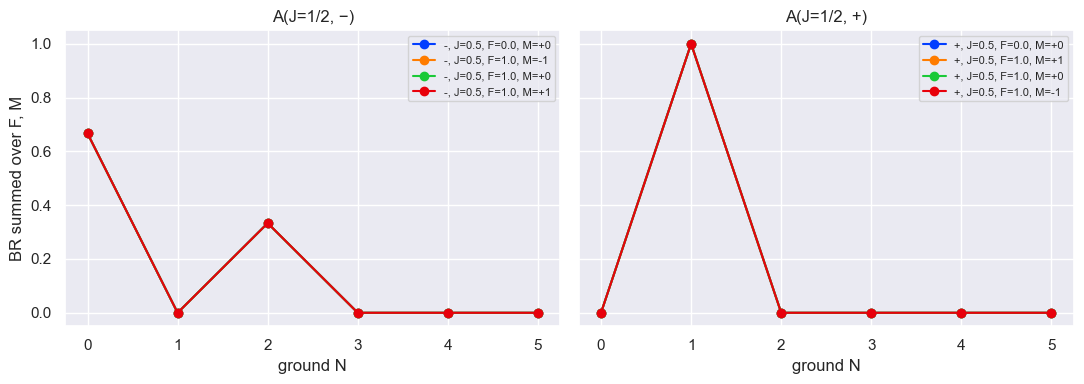

In [10]:
def br_by_N(j, BR, X, N_range=range(0, 6)):
    out = {}
    for N in N_range:
        mask = np.array([X.q_numbers['N'][np.argmax(X.evecs0[i]**2)] == N
                         for i in range(X.size)])
        out[N] = BR[j, mask].sum()
    return out


fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, eidx_set, title in [(axes[0], eidx_minus, "A(J=1/2, −)"),
                            (axes[1], eidx_plus,  "A(J=1/2, +)")]:
    for j in eidx_set:
        d = br_by_N(j, BR, X)
        ax.plot(list(d.keys()), list(d.values()), 'o-', label=label_state(A, j))
    ax.set_xlabel("ground N")
    ax.set_title(title)
    ax.legend(fontsize=8)
axes[0].set_ylabel("BR summed over F, M")
plt.tight_layout()
plt.show()

## Cross-check: properly-normalized table for one excited state

Reproduce a BaF-style table for the first A(J=1/2, −) eigenstate, but now showing **all** dipole-allowed ground states and confirming sum BR = 1.

In [11]:
j0 = int(eidx_minus[0])
br_row = BR[j0]
rows = []
for i in np.argsort(-br_row):
    if br_row[i] < 1e-5:
        continue
    rows.append((label_state(X, i), float(nu_cm[j0, i]), f"{br_row[i]:.6f}"))
print(f"Excited state: {label_state(A, j0)}")
print(f"sum BR = {br_row.sum():.6f}")
print(tabulate(rows, headers=["ground state", "ν (cm⁻¹)", "BR"], tablefmt="fancy_grid"))

Excited state: -, J=0.5, F=0.0, M=+0
sum BR = 1.000000
╒══════════════════════════╤════════════╤══════════╕
│ ground state             │   ν (cm⁻¹) │       BR │
╞══════════════════════════╪════════════╪══════════╡
│ N=0+, J=0.5, F=1.0, M=+1 │    12609.6 │ 0.222201 │
├──────────────────────────┼────────────┼──────────┤
│ N=0+, J=0.5, F=1.0, M=+0 │    12609.6 │ 0.222201 │
├──────────────────────────┼────────────┼──────────┤
│ N=0+, J=0.5, F=1.0, M=-1 │    12609.6 │ 0.222201 │
├──────────────────────────┼────────────┼──────────┤
│ N=2+, J=1.5, F=1.0, M=-1 │    12608.5 │ 0.111132 │
├──────────────────────────┼────────────┼──────────┤
│ N=2+, J=1.5, F=1.0, M=+0 │    12608.5 │ 0.111132 │
├──────────────────────────┼────────────┼──────────┤
│ N=2+, J=1.5, F=1.0, M=+1 │    12608.5 │ 0.111132 │
╘══════════════════════════╧════════════╧══════════╛
